In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("sales.csv")

In [27]:
df = pd.read_csv("sales.csv")

In [28]:
df.head()


,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday


In [29]:
df.shape

(2800, 10)

In [30]:
df.columns

Index(['store_id', 'product_id', 'date', 'category', 'price',
       'promotion_active', 'discount_percent', 'units_sold', 'inventory_level',
       'day_of_week'],
      dtype='object')

In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2800 entries, 0 to 2799
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   store_id          2800 non-null   int64 
 1   product_id        2800 non-null   int64 
 2   date              2800 non-null   object
 3   category          2800 non-null   object
 4   price             2800 non-null   int64 
 5   promotion_active  2800 non-null   object
 6   discount_percent  2800 non-null   int64 
 7   units_sold        2800 non-null   int64 
 8   inventory_level   2800 non-null   int64 
 9   day_of_week       2800 non-null   object
dtypes: int64(6), object(4)
memory usage: 218.9+ KB


In [32]:
df.describe()

,store_id,product_id,price,discount_percent,units_sold,inventory_level
count,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000,2800.000000
mean,25.381429,1495.836429,1518.536786,6.844643,26.290000,254.571429
std,14.217981,290.054812,846.448062,9.643473,11.378834,139.007945
min,1.000000,1000.000000,50.000000,0.000000,1.000000,20.000000
25%,13.000000,1242.000000,792.750000,0.000000,17.000000,134.000000
50%,25.000000,1497.500000,1533.000000,0.000000,26.000000,254.500000
75%,38.000000,1750.250000,2246.250000,15.000000,35.000000,376.250000
max,50.000000,2000.000000,3000.000000,30.000000,56.000000,500.000000


In [33]:
df.isnull().sum()

store_id            0
product_id          0
date                0
category            0
price               0
promotion_active    0
discount_percent    0
units_sold          0
inventory_level     0
day_of_week         0
dtype: int64

In [34]:
df.duplicated().sum()

np.int64(0)

In [35]:
df['date'] = pd.to_datetime(df['date'])

In [36]:
df.head()

,store_id,product_id,date,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week
0,12,1823,2024-09-19,Home,1902,No,0,17,251,Friday
1,6,1551,2024-12-21,Grocery,2629,Yes,0,14,248,Wednesday
2,40,1015,2024-09-27,Grocery,2488,No,0,25,251,Saturday
3,50,1475,2024-06-16,Home,293,Yes,5,7,470,Tuesday
4,32,1004,2024-12-05,Grocery,2470,Yes,20,37,139,Saturday


In [37]:
df['category'].unique()

array(['Home', 'Grocery', 'Electronics', 'Clothing', 'Personal Care'],
      dtype=object)

In [38]:
df['promotion_active'].unique()

array(['No', 'Yes'], dtype=object)

In [39]:
import pandas as pd


df['date'] = pd.to_datetime(df['date'])

# Create separate columns
df['day'] = df['date'].dt.day
df['month'] = df['date'].dt.month
df['year'] = df['date'].dt.year


df.drop('date', axis=1, inplace=True)


df.head()

,store_id,product_id,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day,month,year
0,12,1823,Home,1902,No,0,17,251,Friday,19,9,2024
1,6,1551,Grocery,2629,Yes,0,14,248,Wednesday,21,12,2024
2,40,1015,Grocery,2488,No,0,25,251,Saturday,27,9,2024
3,50,1475,Home,293,Yes,5,7,470,Tuesday,16,6,2024
4,32,1004,Grocery,2470,Yes,20,37,139,Saturday,5,12,2024


In [40]:
df.drop('store_id', axis=1, inplace=True)


df.head()

,product_id,category,price,promotion_active,discount_percent,units_sold,inventory_level,day_of_week,day,month,year
0,1823,Home,1902,No,0,17,251,Friday,19,9,2024
1,1551,Grocery,2629,Yes,0,14,248,Wednesday,21,12,2024
2,1015,Grocery,2488,No,0,25,251,Saturday,27,9,2024
3,1475,Home,293,Yes,5,7,470,Tuesday,16,6,2024
4,1004,Grocery,2470,Yes,20,37,139,Saturday,5,12,2024


In [42]:
df.to_csv("retail_sales_cleaned.csv", index=False)

In [ ]:
### EDA

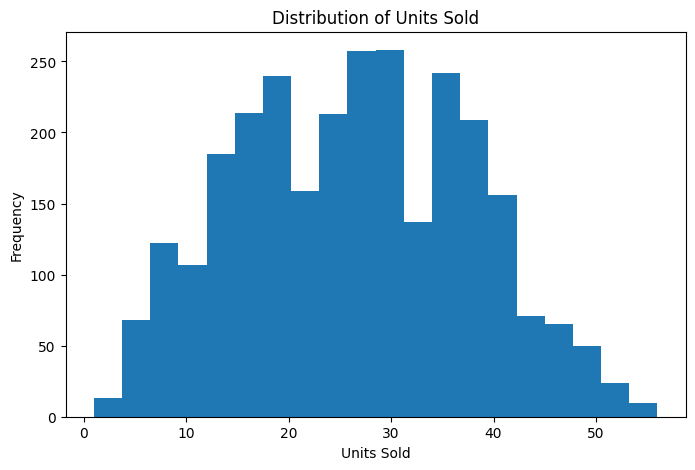

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['units_sold'], bins=20)
plt.title('Distribution of Units Sold')
plt.xlabel('Units Sold')
plt.ylabel('Frequency')
plt.show()

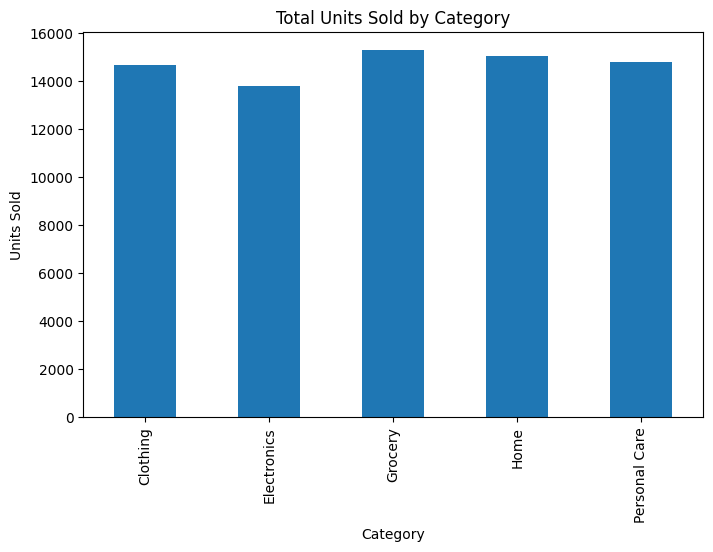

In [44]:
category_sales = df.groupby('category')['units_sold'].sum()

category_sales.plot(kind='bar', figsize=(8,5))
plt.title('Total Units Sold by Category')
plt.xlabel('Category')
plt.ylabel('Units Sold')
plt.show()

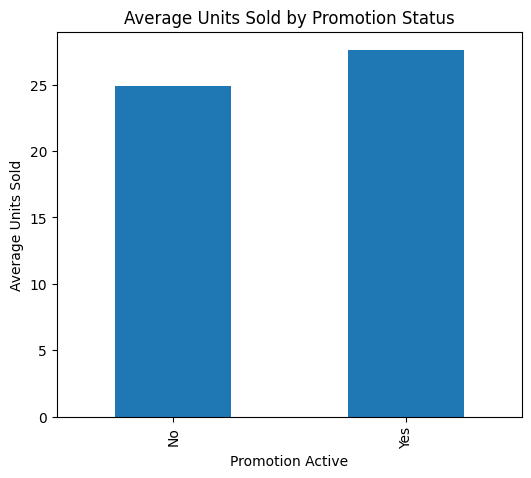

In [46]:
promotion_sales = df.groupby('promotion_active')['units_sold'].mean()

promotion_sales.plot(kind='bar', figsize=(6,5))
plt.title('Average Units Sold by Promotion Status')
plt.xlabel('Promotion Active')
plt.ylabel('Average Units Sold')
plt.show()

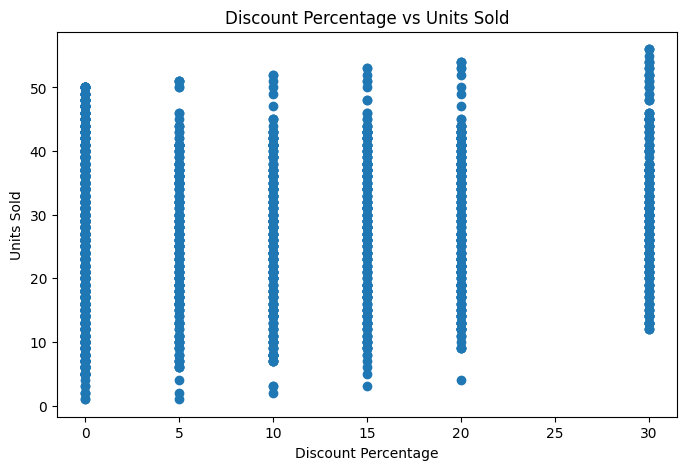

In [47]:
plt.figure(figsize=(8,5))
plt.scatter(df['discount_percent'], df['units_sold'])
plt.title('Discount Percentage vs Units Sold')
plt.xlabel('Discount Percentage')
plt.ylabel('Units Sold')
plt.show()

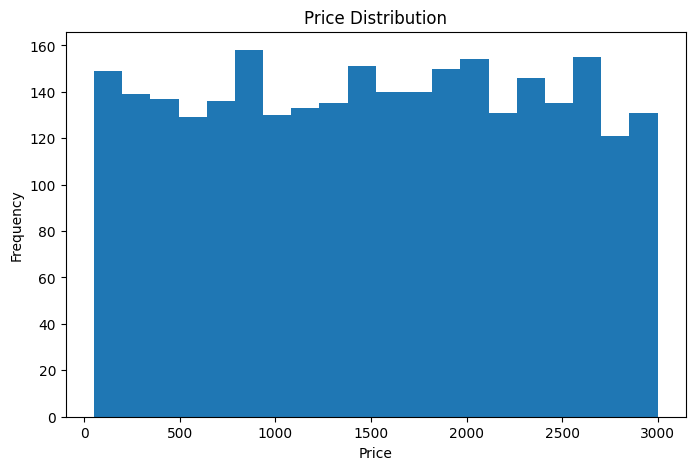

In [48]:
plt.figure(figsize=(8,5))
plt.hist(df['price'], bins=20)
plt.title('Price Distribution')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

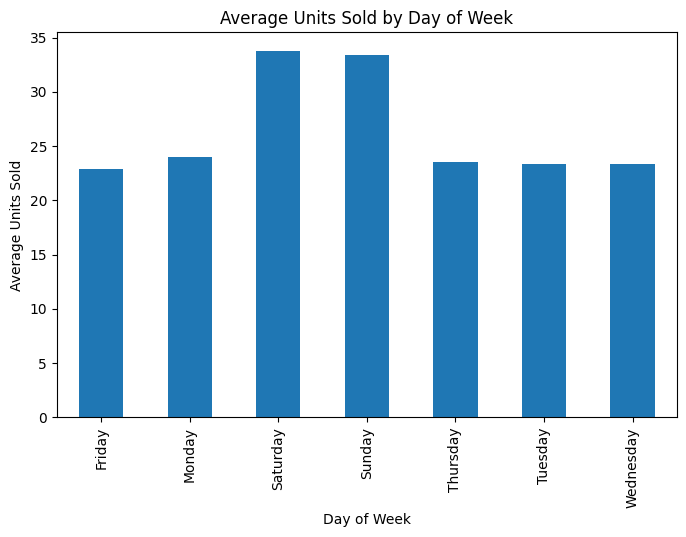

In [49]:
day_sales = df.groupby('day_of_week')['units_sold'].mean()

day_sales.plot(kind='bar', figsize=(8,5))
plt.title('Average Units Sold by Day of Week')
plt.xlabel('Day of Week')
plt.ylabel('Average Units Sold')
plt.show()

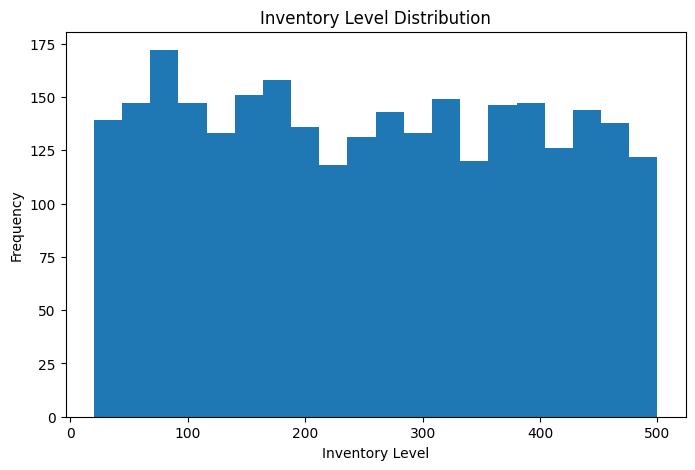

In [50]:
plt.figure(figsize=(8,5))
plt.hist(df['inventory_level'], bins=20)
plt.title('Inventory Level Distribution')
plt.xlabel('Inventory Level')
plt.ylabel('Frequency')
plt.show()

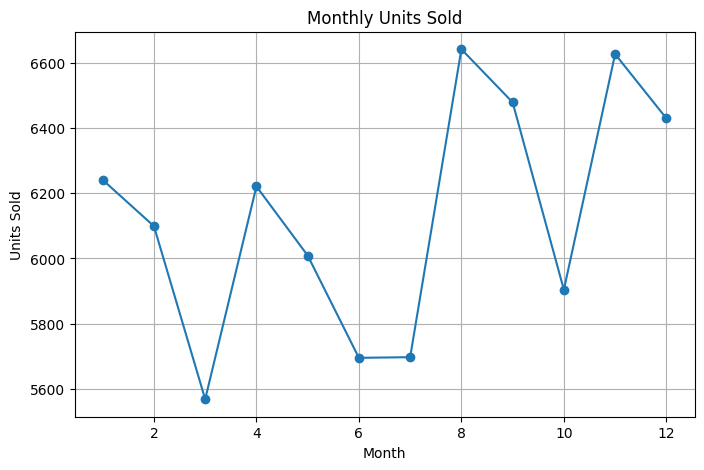

In [51]:
monthly_sales = df.groupby('month')['units_sold'].sum()

monthly_sales.plot(marker='o', figsize=(8,5))
plt.title('Monthly Units Sold')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.grid(True)
plt.show()

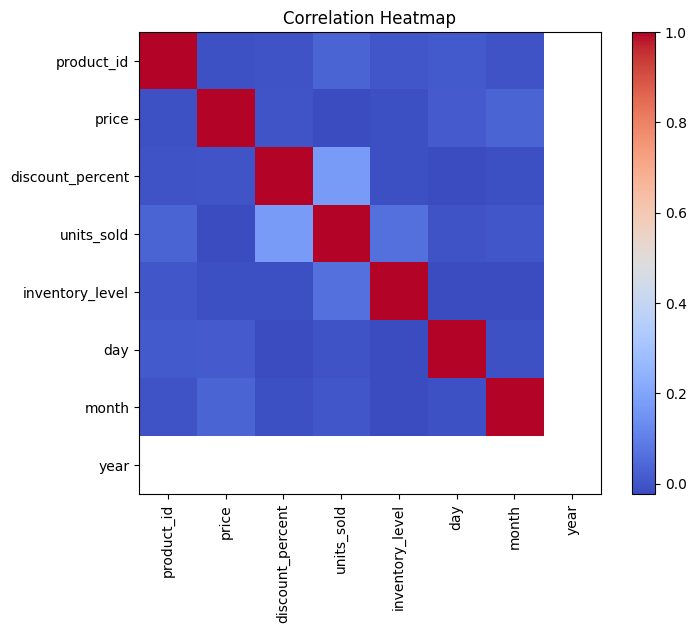

In [52]:
import matplotlib.pyplot as plt

numeric_df = df.select_dtypes(include=['number'])

corr = numeric_df.corr()

plt.figure(figsize=(8,6))
plt.imshow(corr, cmap='coolwarm', interpolation='nearest')
plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)
plt.yticks(range(len(corr.columns)), corr.columns)

plt.title('Correlation Heatmap')
plt.show()

In [ ]:

## Feature Engineering & Machine Learning

In [54]:
y = df['units_sold']
X = df.drop('units_sold', axis=1)

In [55]:
X = pd.get_dummies(X, columns=['category', 'day_of_week'], drop_first=True)

In [56]:
X.head()

,product_id,price,promotion_active,discount_percent,inventory_level,day,month,year,category_Electronics,category_Grocery,category_Home,category_Personal Care,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday
0,1823,1902,No,0,251,19,9,2024,False,False,True,False,False,False,False,False,False,False
1,1551,2629,Yes,0,248,21,12,2024,False,True,False,False,False,False,False,False,False,True
2,1015,2488,No,0,251,27,9,2024,False,True,False,False,False,True,False,False,False,False
3,1475,293,Yes,5,470,16,6,2024,False,False,True,False,False,False,False,False,True,False
4,1004,2470,Yes,20,139,5,12,2024,False,True,False,False,False,True,False,False,False,False


In [58]:
pip install scikit-learn

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ------------ --------------------------- 2.6/8.2 MB 13.8 MB/s eta 0:00:01
   -------------------------- ------------- 5.5/8.2 MB 14.0 MB/s eta 0:00:01
   ---------------------------------------  8.1/8.2 MB 13.6 MB/s eta 0:00:01
   ---------------------------------------- 8.2/8.2 MB 13.4 MB/s  0:00:00
   ---------------------------------------- 0.0/36.6 MB ? eta -:--:--
   --- ------------------------------------ 2.9/36.6 MB 15.3 MB/s eta 0:00:03
   ------ --------------------------------- 5.8/36.6 MB 14.1 MB/s eta 0:00:03
   --------- ------------------------------ 8.7/36.6 MB 14.1 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/36.6 MB 13.9 MB/s eta 0:00:02
   --------------- ------------------------ 14.4/36.6 MB 13.9 MB/s eta 0:00:02
   ------------------ --------------------- 17.0/36.6 MB 13.9 MB/s eta 0:00:02
   -------------

In [59]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [60]:
print(X_train.shape)
print(X_test.shape)

print(y_train.shape)
print(y_test.shape)

(2240, 18)
(560, 18)
(2240,)
(560,)


In [61]:
X.to_csv("prepared_features.csv", index=False)

In [62]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [63]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

In [64]:
model.fit(X_train, y_train)

ValueError: could not convert string to float: 'Yes'

In [65]:
X.dtypes

product_id                 int64
price                      int64
promotion_active          object
discount_percent           int64
inventory_level            int64
day                        int32
month                      int32
year                       int32
category_Electronics        bool
category_Grocery            bool
category_Home               bool
category_Personal Care      bool
day_of_week_Monday          bool
day_of_week_Saturday        bool
day_of_week_Sunday          bool
day_of_week_Thursday        bool
day_of_week_Tuesday         bool
day_of_week_Wednesday       bool
dtype: object

In [67]:
X['promotion_active'] = X['promotion_active'].map({
    'Yes': 1,
    'No': 0
})

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [69]:
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease o

In [70]:

y_pred = model.predict(X_test)

In [71]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Mean Absolute Error (MAE): 9.109
Root Mean Squared Error (RMSE): 10.620711336144783
R² Score: 0.06320043982584922


In [72]:
results = X_test.copy()
results['Actual Units Sold'] = y_test.values
results['Predicted Units Sold'] = y_pred

results.head(10)

,product_id,price,promotion_active,discount_percent,inventory_level,day,month,year,category_Electronics,category_Grocery,category_Home,category_Personal Care,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,Actual Units Sold,Predicted Units Sold
1088,1141,1310,0,0,327,11,5,2024,False,False,False,True,False,False,False,True,False,False,21,21.41
772,1746,2120,1,10,304,5,5,2024,False,False,False,False,True,False,False,False,False,False,28,26.44
2161,1426,2472,1,30,46,2,3,2024,False,True,False,False,False,True,False,False,False,False,23,29.45
1192,1692,564,0,0,135,2,11,2024,True,False,False,False,False,False,False,False,True,False,10,22.48
1916,1267,1703,1,20,140,21,6,2024,False,False,True,False,False,False,False,True,False,False,22,27.03
1614,1217,2873,0,0,498,20,11,2024,False,False,True,False,False,True,False,False,False,False,40,35.03
1399,1250,2448,1,5,199,22,8,2024,True,False,False,False,False,True,False,False,False,False,24,38.95
1461,1932,2095,1,0,57,23,8,2024,False,True,False,False,False,False,False,True,False,False,9,24.68
2222,1458,1930,1,30,486,5,7,2024,False,True,False,False,False,False,False,True,False,False,18,30.36
1114,1325,1971,1,5,118,15,3,2024,False,False,False,False,False,False,False,True,False,False,25,28.04


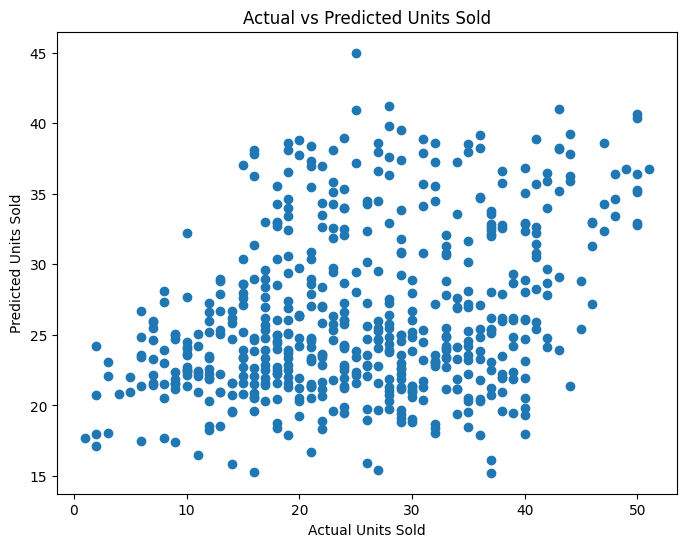

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)

plt.xlabel("Actual Units Sold")
plt.ylabel("Predicted Units Sold")
plt.title("Actual vs Predicted Units Sold")

plt.show()

In [74]:
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
})

importance = importance.sort_values(by='Importance', ascending=False)

importance.head(10)

,Feature,Importance
4,inventory_level,0.184521
1,price,0.150135
0,product_id,0.146073
5,day,0.108955
14,day_of_week_Sunday,0.087411
13,day_of_week_Saturday,0.087156
6,month,0.076996
3,discount_percent,0.053865
10,category_Home,0.014293
9,category_Grocery,0.014215
